In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

def scat(x, y, c,marker):
    return ax.scatter(x, y*100, c=c, ls='-', cmap=cmap, norm=norm, s=30, marker=marker
                     )
import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein
sys.path.append('../survey_design/')
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

In [2]:
import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

In [3]:
path = '../survey_design/telescope_and_science_metrics/'

In [4]:
survey_design_dark = load(path + 'survey_design_Dark_lbg_only_fnl_neutrinos_forecast.pkl')
survey_design_dark_qso = load(path + 'survey_design_Dark_qso_only.pkl')
survey_design_dark_one_tracer = load(path + 'survey_design_Dark_lbg_only_fnl_neutrinos_forecast_onetracer_approach.pkl')

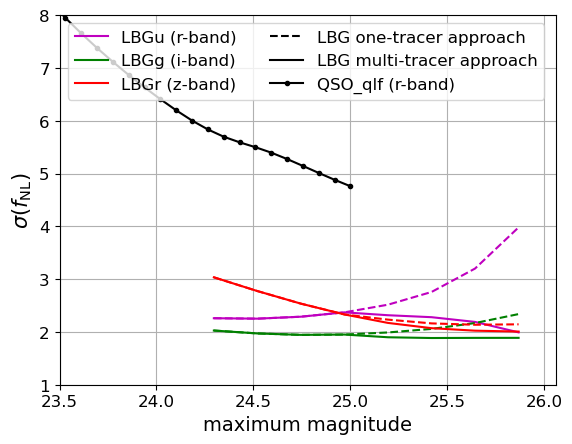

In [13]:
n=0
for k, tracer in enumerate(['LBGu', 'LBGg', 'LBGr']):
    
    survey = survey_design_dark

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]

    x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_fnl_eff'])
    plt.plot(x, y,  label = tracer+ f' ({survey["config_survey"]["limiting_mag_band"][k]}-band)',
                 color = color, 
                 marker='', )

    x, y = survey_design_dark_one_tracer['config_survey'][tracer+'_mag_centers'], np.array(survey_design_dark_one_tracer ['per_tracer_forecasts'][tracer+'_sigma_fnl_eff'])
    plt.plot(x, y, ls='--',
                 color = color, 
                 )

    #plt.xlim(2, 6)
    plt.ylim(1, 5)
plt.ylabel(r'$\sigma(f_{\rm NL})$', fontsize=15)
plt.xlabel(r'maximum magnitude', fontsize=14)
plt.plot([], [], '--k', label = 'LBG one-tracer approach')
plt.plot([], [], '-k', label = 'LBG multi-tracer approach')

plt.tick_params(axis='both', labelsize=12)

survey = survey_design_dark_qso

mask_color = np.array(survey['config_survey']['tracers'])=='QSO_qlf'

color = np.array(survey['config_survey']['color'])[mask_color][0]

x, y = survey['config_survey']['QSO_qlf_mag_centers'], np.array(survey['per_tracer_forecasts']['QSO_qlf_sigma_fnl_eff'])
plt.plot(x, y,  label = 'QSO_qlf (r-band)',
             color = 'k', 
             marker='o', markersize=3)


plt.ylim(1, 8)
plt.xlim(23.5)
plt.grid()

plt.legend(fontsize=12, ncols=2, loc='upper left')

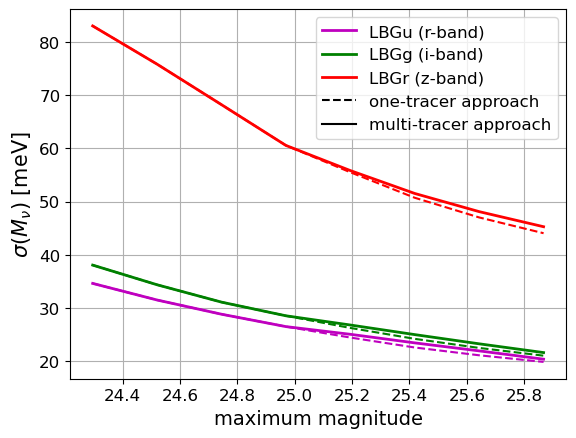

In [7]:
n=0
for k, tracer in enumerate(['LBGu', 'LBGg', 'LBGr']):
    
    survey = survey_design_dark

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]

    x, y = survey['config_survey'][tracer+'_mag_centers'], 1000*np.array(survey['per_tracer_forecasts'][tracer+'_sigma_Mnu_eff'])
    plt.plot(x, y,  label = tracer+ f' ({survey["config_survey"]["limiting_mag_band"][k]}-band)',lw=2,
                 color = color, 
                 marker='', )

    x, y = survey_design_dark_one_tracer['config_survey'][tracer+'_mag_centers'], 1000*np.array(survey_design_dark_one_tracer ['per_tracer_forecasts'][tracer+'_sigma_Mnu_eff'])
    plt.plot(x, y, ls='--',
                 color = color, 
                 )

    #plt.xlim(2, 6)
    #plt.ylim(1, 10)
plt.grid()
plt.ylabel(r'$\sigma(M_\nu)$ [meV]', fontsize=15)
plt.xlabel(r'maximum magnitude', fontsize=14)
plt.plot([], [], '--k', label = 'one-tracer approach')
plt.plot([], [], '-k', label = 'multi-tracer approach')

plt.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=12, ncols=1, loc='upper right')